<a href="https://colab.research.google.com/github/dr-koehler-ai/Heart-Failure-Clinical-Records-Dashboard/blob/main/Heart_Failure_Clinical_Records_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Heart Failure Survival Prediction V2**

*Objective*

*   Predict Mortality using machine learning models

*Dataset*
*   299 patients
*   13 clinical features
*   binary outcome (target variable: death event)


*Workflow*
*   Data cleaning (V1)
*   EDA (V1)
*   Statistical Analysis (V1)
*   Logistic Regression (V1)
*   Machine Learning

*Clinical question*

Can clinical variables be used to predict mortality in heart failure patients, based on a simple baseline model?

In [30]:
# Heart Failure Clinical Records Dashboard (V2)
# =========================================

#Standard library

#Data manipulation
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np

#Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Statistics
from scipy import stats
from statistics import mean, stdev
from math import sqrt

# Data preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample

# Data modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score

# Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from xgboost import XGBClassifier
from xgboost import plot_importance

# =========================
# 1. Dataset Download
# =========================

from google.colab import drive
drive.mount("/content/drive")

dataset_path = Path("/content/drive/MyDrive/AI_Healthcare/Heart_Failure/heart_failure_clinical_records.csv")

data = pd.read_csv(dataset_path)

data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


As the independent variables are all continuous, **a Gaussian Naive Bayes Model** was selected for first analysis.

              precision    recall  f1-score   support

           0       0.75      0.98      0.85        51
           1       0.88      0.29      0.44        24

    accuracy                           0.76        75
   macro avg       0.81      0.64      0.64        75
weighted avg       0.79      0.76      0.72        75



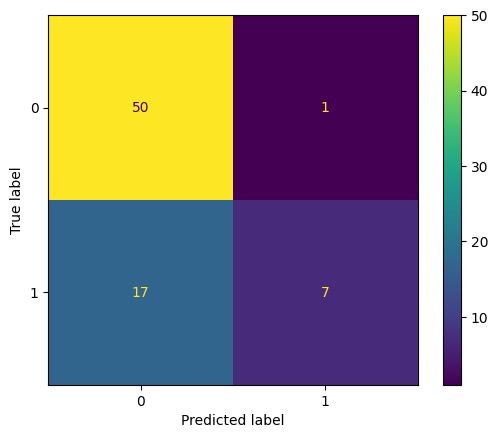

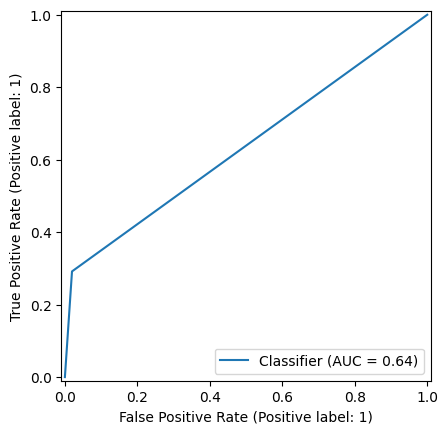

In [31]:
from sklearn.naive_bayes import GaussianNB

data.columns.tolist()

#Defining variables and target
y = data["death_event"]
X = data[[
 'age',
 'ejection_fraction',
 'platelets',
 'serum_creatinine']]

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Building the model
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gnb.classes_)
disp.plot()
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred)
plt.show()

**Data Scaling**


*   not much of a help

In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = gnb_scaled.predict(X_test_scaled)

print(classification_report(y_test, y_pred_scaled))

              precision    recall  f1-score   support

           0       0.73      0.90      0.81        51
           1       0.58      0.29      0.39        24

    accuracy                           0.71        75
   macro avg       0.66      0.60      0.60        75
weighted avg       0.68      0.71      0.67        75



**Decision Tree**

              precision    recall  f1-score   support

           0       0.75      0.98      0.85        51
           1       0.88      0.29      0.44        24

    accuracy                           0.76        75
   macro avg       0.81      0.64      0.64        75
weighted avg       0.79      0.76      0.72        75

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


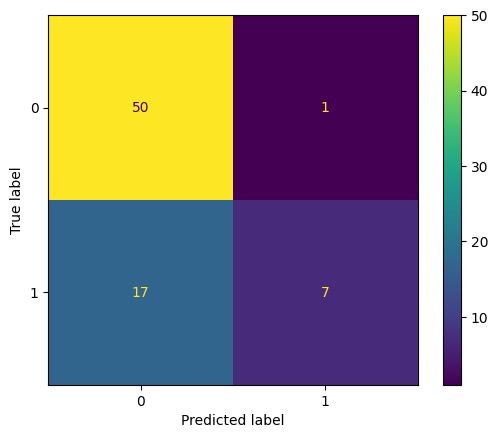

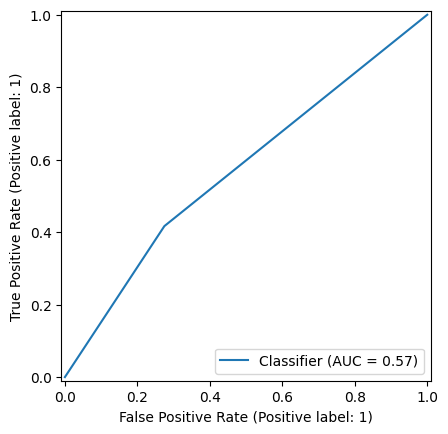

              precision    recall  f1-score   support

           0       0.73      0.73      0.73        51
           1       0.42      0.42      0.42        24

    accuracy                           0.63        75
   macro avg       0.57      0.57      0.57        75
weighted avg       0.63      0.63      0.63        75



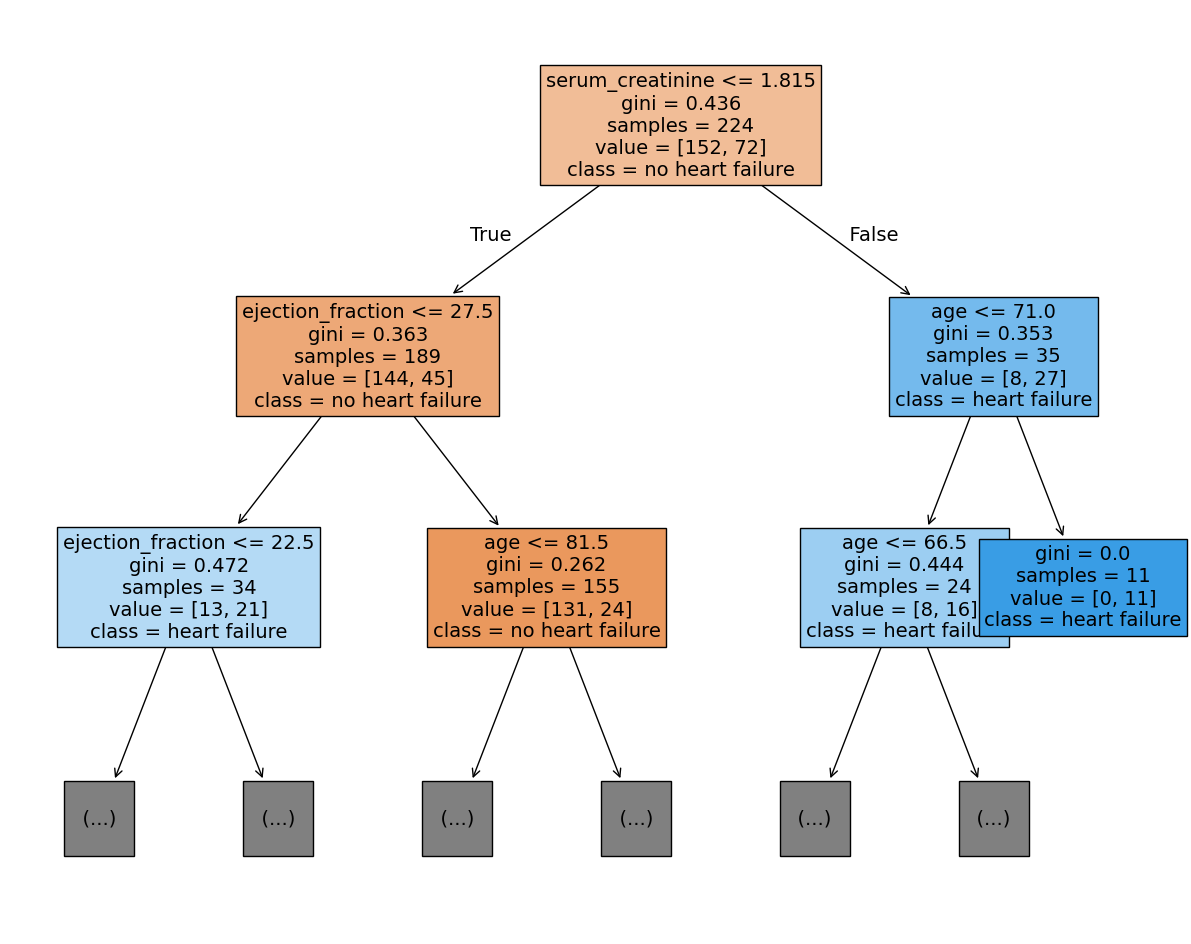

In [32]:
# Building the model
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred_tree = decision_tree.predict(X_test)

# Classification Report & best parameters
print(classification_report(y_test, y_pred))
print(decision_tree.get_params())

# Confusion Matrix
cm_tree = confusion_matrix(y_test, y_pred)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=decision_tree.classes_)
disp_tree.plot()
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_tree)
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_tree))

# Plotting Decision Tree
plt.figure(figsize=(15,12))
plot_tree(decision_tree, max_depth=2, fontsize=14, class_names = {0: "no heart failure", 1: "heart failure"}, feature_names=X.columns, filled=True)
plt.show()


**GridSearchCV for tuning Decision Tree**

              precision    recall  f1-score   support

           0       0.77      0.86      0.81        51
           1       0.61      0.46      0.52        24

    accuracy                           0.73        75
   macro avg       0.69      0.66      0.67        75
weighted avg       0.72      0.73      0.72        75

{'max_depth': 4, 'min_samples_leaf': 5}


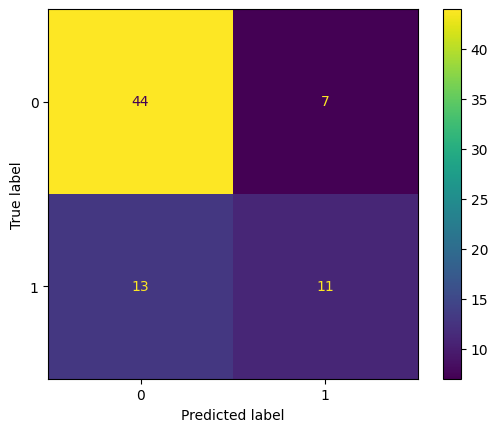

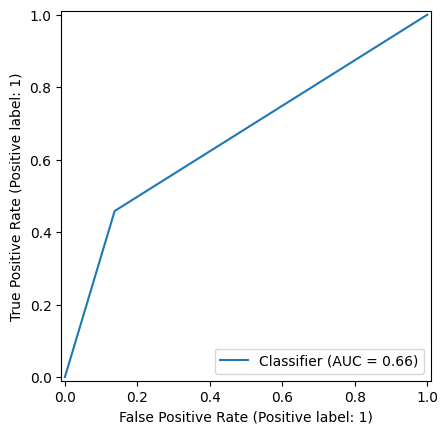

              precision    recall  f1-score   support

           0       0.77      0.86      0.81        51
           1       0.61      0.46      0.52        24

    accuracy                           0.73        75
   macro avg       0.69      0.66      0.67        75
weighted avg       0.72      0.73      0.72        75



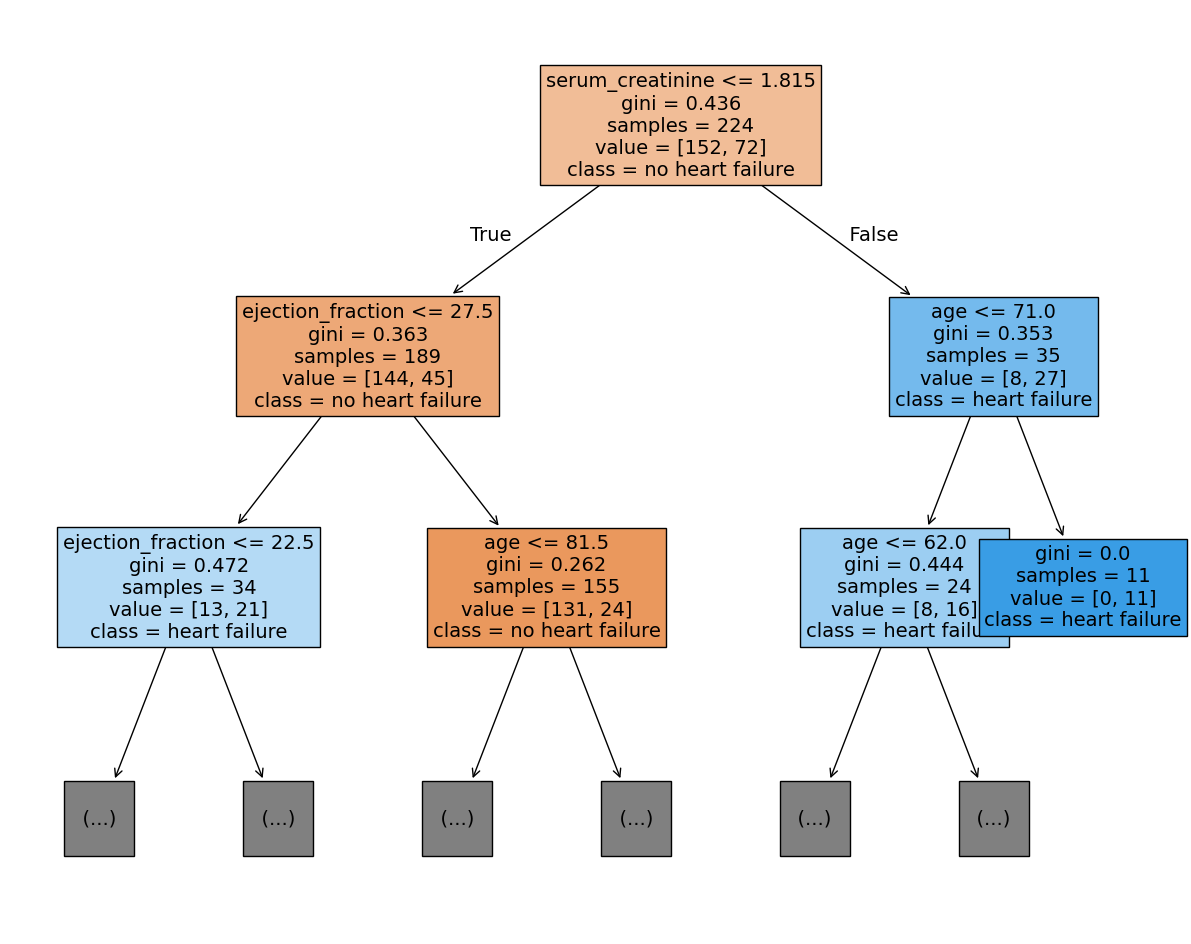

In [33]:
tree_para = {"max_depth": [4,5,6,7,8,9,10],
             "min_samples_leaf": [2,5,10]}
scoring = ["precision", "recall", "accuracy", "f1"]

#Building model
tuned_decision_tree = DecisionTreeClassifier(random_state=42)
tree_cv = GridSearchCV(tuned_decision_tree, tree_para, cv=5, scoring=scoring, refit="recall")
tree_cv.fit(X_train, y_train)
y_pred_tuned = tree_cv.predict(X_test)

# Classification Report
print(classification_report(y_test, y_pred_tuned))
print(tree_cv.best_params_)

# Confusion Matrix
cm_tree_tuned = confusion_matrix(y_test, y_pred_tuned)
disp_tree_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tree_tuned, display_labels=tree_cv.classes_)
disp_tree_tuned.plot()
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_tuned)
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_tuned))

# Plotting Decision Tree
plt.figure(figsize=(15,12))
plot_tree(tree_cv.best_estimator_, max_depth=2, fontsize=14, class_names = {0: "no heart failure", 1: "heart failure"}, feature_names=X.columns, filled=True)
plt.show()

**Random Forrest**

              precision    recall  f1-score   support

           0       0.77      0.84      0.80        51
           1       0.58      0.46      0.51        24

    accuracy                           0.72        75
   macro avg       0.67      0.65      0.66        75
weighted avg       0.71      0.72      0.71        75

{'max_depth': None, 'max_features': 4, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 75}


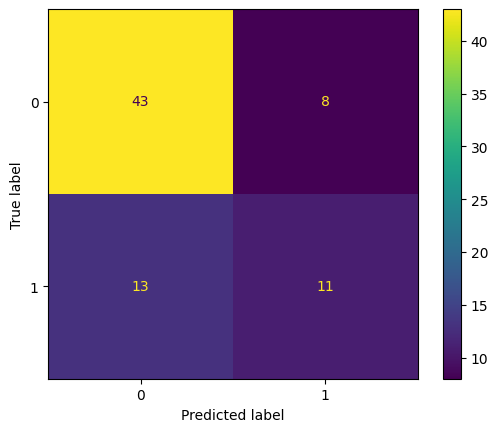

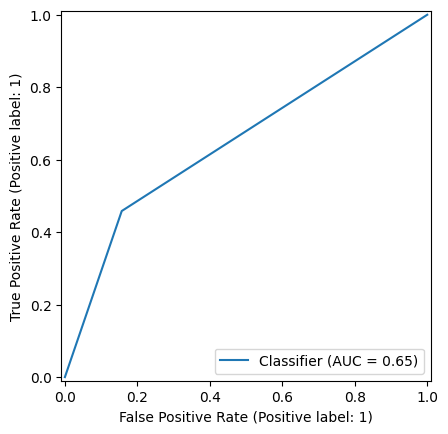

              precision    recall  f1-score   support

           0       0.77      0.84      0.80        51
           1       0.58      0.46      0.51        24

    accuracy                           0.72        75
   macro avg       0.67      0.65      0.66        75
weighted avg       0.71      0.72      0.71        75



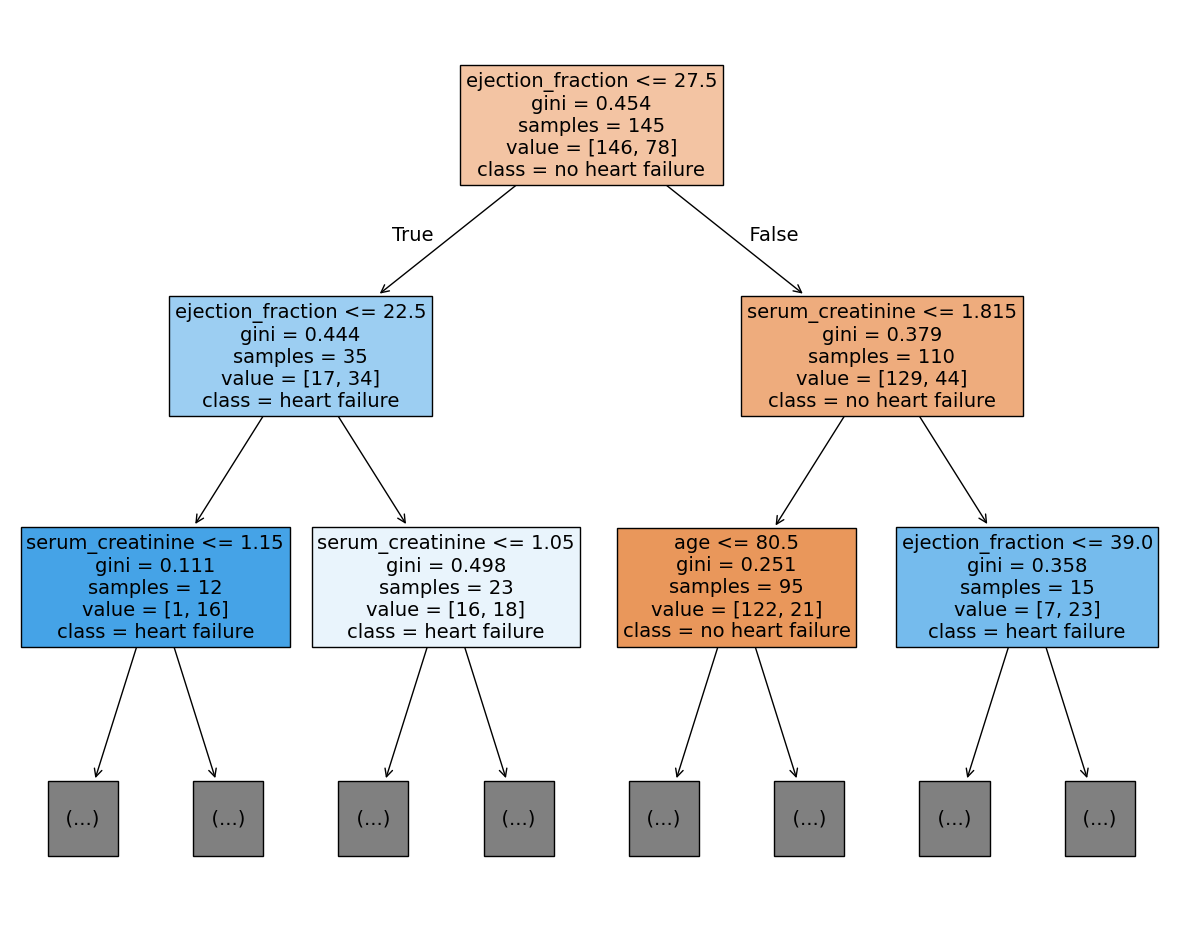

CPU times: user 6min 29s, sys: 1.02 s, total: 6min 30s
Wall time: 6min 32s


In [36]:
%%time

forest_para = {"max_depth": [2,3,4,5,None],
               "min_samples_leaf": [1,2,3],
               "min_samples_split": [2,3,4],
               "max_features": [2,3,4],
               "n_estimators": [75,100, 125,150]}
scoring = ["precision", "recall", "accuracy", "f1"]

#Building model
rf = RandomForestClassifier(random_state=42)
rf_cv = GridSearchCV(rf, forest_para, cv=5, scoring=scoring, refit="recall")
rf_cv.fit(X_train, y_train)
y_pred_rf = rf_cv.predict(X_test)

# Classification Report
print(classification_report(y_test, y_pred_rf))
print(rf_cv.best_params_)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_cv.classes_)
disp_rf.plot()
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_rf))

# Plotting Decision Tree (first estimator from the Random Forest)
plt.figure(figsize=(15,12))
plot_tree(rf_cv.best_estimator_.estimators_[0], max_depth=2, fontsize=14, class_names = {0: "no heart failure", 1: "heart failure"}, feature_names=X.columns, filled=True)
plt.show()

In [38]:
import pickle

path = "/content/drive/MyDrive/AI_Healthcare/Heart_Failure/"

with open(path + "rf_cv_model.pickle", "wb") as to_write:
    pickle.dump(rf_cv, to_write)

In [ ]:
with open(path + "rf_cv_model.pickle", "rb") as to_read:
    rf_cv = pickle.load(to_read)

**XGBoost**

              precision    recall  f1-score   support

           0       0.75      0.75      0.75        51
           1       0.46      0.46      0.46        24

    accuracy                           0.65        75
   macro avg       0.60      0.60      0.60        75
weighted avg       0.65      0.65      0.65        75

{'learning_rate': 0.2, 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 125}


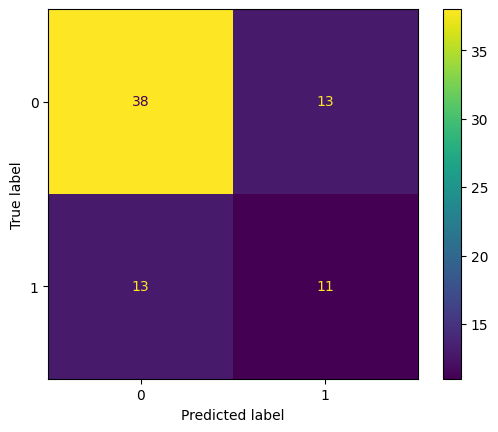

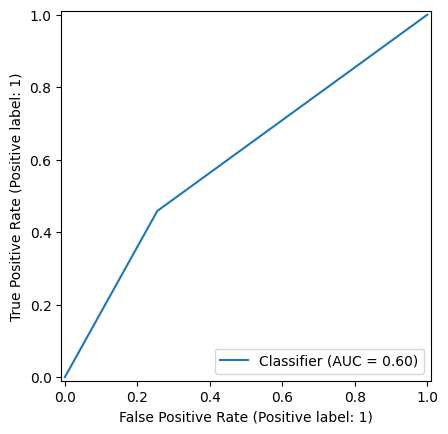

              precision    recall  f1-score   support

           0       0.75      0.75      0.75        51
           1       0.46      0.46      0.46        24

    accuracy                           0.65        75
   macro avg       0.60      0.60      0.60        75
weighted avg       0.65      0.65      0.65        75



<Figure size 1000x800 with 0 Axes>

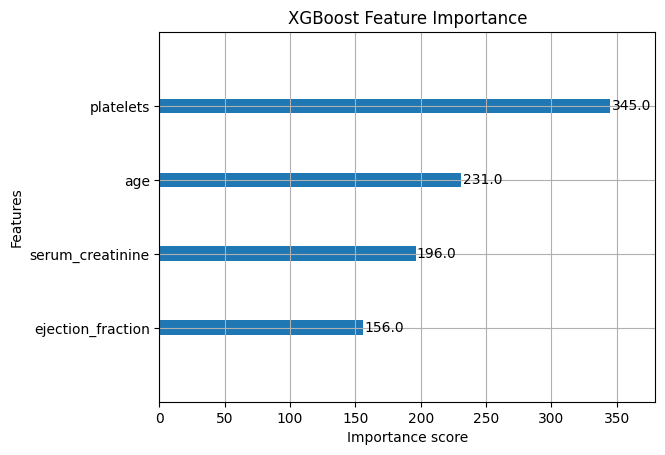

In [40]:
xgb_para = {"max_depth": [4,5,6,7,8],
               "min_child_weight": [1,2,3,4,5],
               "learning_rate": [0.1,0.2,0.3],
               "n_estimators": [75,100, 125]}
scoring = ["precision", "recall", "accuracy", "f1"]

#Building model
xgb = XGBClassifier(objective="binary:logistic",random_state=42)
xgb_cv = GridSearchCV(xgb, xgb_para, cv=5, scoring=scoring, refit="recall")
xgb_cv.fit(X_train, y_train) # Korrigiert: rf_cv.fit() zu xgb_cv.fit()
y_pred_xgb = xgb_cv.predict(X_test) # Korrigiert: rf_cv.predict() zu xgb_cv.predict()

# Classification Report
print(classification_report(y_test, y_pred_xgb))
print(xgb_cv.best_params_)

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=xgb_cv.classes_)
disp_xgb.plot()
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_xgb)
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_xgb))

# Plotting Feature Importance for XGBoost
plt.figure(figsize=(10, 8))
plot_importance(xgb_cv.best_estimator_)
plt.title("XGBoost Feature Importance")
plt.show()

In [41]:
import pickle

path = "/content/drive/MyDrive/AI_Healthcare/Heart_Failure/"

with open(path + "xgb_cv_model.pickle", "wb") as to_write:
    pickle.dump(xgb_cv, to_write)

In [ ]:
with open(path + "rf_cv_model.pickle", "rb") as to_read:
    rf_cv = pickle.load(to_read)

**Overview Models**

In [44]:
def make_results(model_name, model_object):
  cv_results = pd.DataFrame(model_object.cv_results_)
  best_estimator_results = cv_results.iloc[cv_results["mean_test_recall"].idxmax(),:]
  recall = best_estimator_results["mean_test_recall"]
  precision = best_estimator_results["mean_test_precision"]
  accuracy = best_estimator_results["mean_test_accuracy"]
  f1 = best_estimator_results["mean_test_f1"]

  table = pd.DataFrame({"Model": [model_name],
                        "F1": [f1],
                        "Recall": [recall],
                        "Accuracy": [accuracy],
                        "Precision": [precision]})
  return table

results_gnb = pd.DataFrame({"Model": ["Gaussian NB"],
                            "F1": [accuracy_score(y_test, y_pred)],
                            "Recall": [recall_score(y_test, y_pred)],
                            "Accuracy": [accuracy_score(y_test, y_pred)],
                            "Precision": [precision_score(y_test, y_pred)]})

results_tree = make_results("Decision Tree", tree_cv)
results_tuned_tree = make_results("Tuned Decision Tree", tree_cv)
results_forest = make_results("Random Forest", rf_cv)
results_xgb = make_results("XGBoost", xgb_cv)

results_overall = pd.concat([results_gnb, results_tree, results_tuned_tree, results_forest, results_xgb], axis=0)
print(results_overall)

                 Model        F1    Recall  Accuracy  Precision
0          Gaussian NB  0.760000  0.291667  0.760000   0.875000
0        Decision Tree  0.578931  0.574286  0.741212   0.599163
0  Tuned Decision Tree  0.578931  0.574286  0.741212   0.599163
0        Random Forest  0.583326  0.572381  0.745859   0.613333
0              XGBoost  0.597950  0.586667  0.759394   0.630891
